In [1]:
# setup/repo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
from scipy.stats import truncnorm
import os
!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

### Propane price escalation rate based on PGST propane billing

Assumptions:
* Data is from Port Gamble Ferrel Gas Comsumption . xlsx
* Reglecting all costs from maintence, service, adjustments, payments or any miscileanus charges that were not associated with any amount of propane delivered
* Each delivery price was divided by the amount of propane delivered to get all values on a $/gallon basis
* Price of propane from 2005 to 2025 was plotted:
  * The linear trendline from 2005 to 2025 was determined an inaccurate representation of the propane cost escaklation rate, as large fluctaions lead to an extremely low value, 0.01%/yr.
  * The linear trendline from 2016 and onward was used to determine the propane cost escalation rate, 7.8%/yr.

Propane deliveries found:  515
Date range:                2005-07-26 → 2026-01-24

── Price Escalation ─────────────────────────────────────────
  Start price (fitted):    $1.70/gal
  End price (fitted):      $1.70/gal
  Linear slope:            $-0.0001/gal per year
  Avg escalation rate:     -0.0%/year
  R²:                      0.000

── Price Summary ────────────────────────────────────────────
count    515.000
mean       1.754
std        0.350
min        1.032
25%        1.507
50%        1.732
75%        1.963
max        3.666


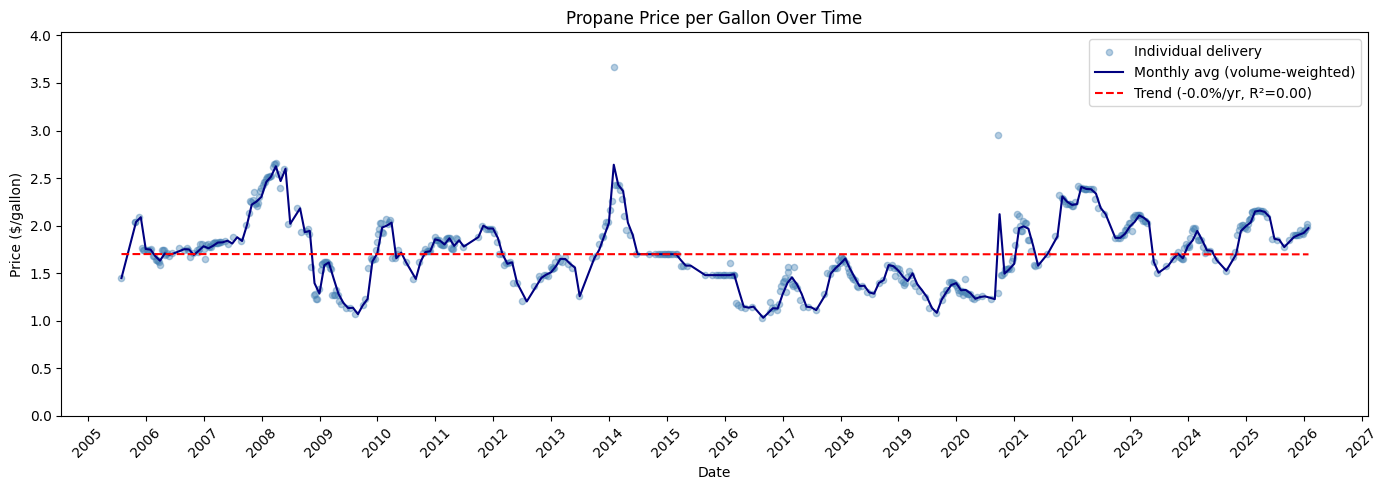

Propane deliveries found:  515
Date range:                2005-07-26 → 2026-01-24

── Price Escalation (2016–present) ──────────────────────────
  Start price (fitted):    $1.22/gal
  End price (fitted):      $2.08/gal
  Linear slope:            $0.0866/gal per year
  Avg escalation rate:     7.1%/year
  R²:                      0.490

── Price Summary (all years) ────────────────────────────────
count    515.000
mean       1.754
std        0.350
min        1.032
25%        1.507
50%        1.732
75%        1.963
max        3.666


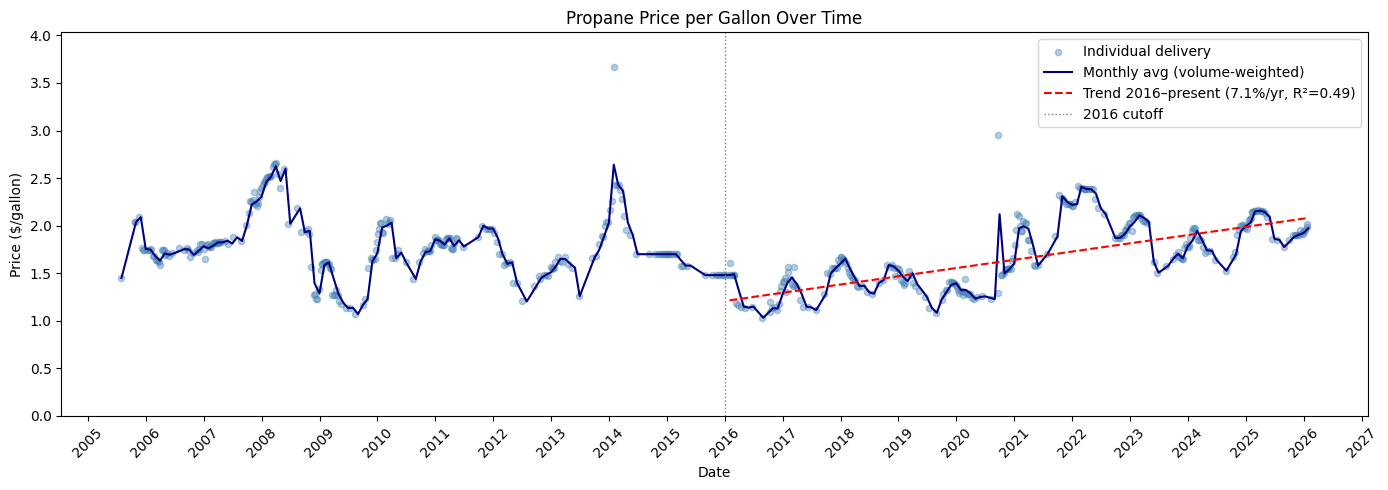

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("Propane Deliveries 2005-2025.csv", header=0)

df = df.rename(columns={
    'Unnamed: 0':  'date',
    'Unnamed: 1':  'description',
    'Unnamed: 2':  'doc_number',
    'Unnamed: 3':  'sale_amount',
    'Unnamed: 4':  'gallons',
    'Unnamed: 5':  'doc_reference',
    'Unnamed: 6':  'payment_amount',
    'Unnamed: 7':  'group',
    'Unnamed: 8':  'gallon_consumption',
    'Unnamed: 9':  'running_total',
    'Unnamed: 10': 'month',
    'Unnamed: 11': 'year',
    'Unnamed: 12': 'month_year',
    'Unnamed: 13': 'monthly_temp_F',
})

df = df[df['date'] != 'Transaction date'].reset_index(drop=True)

# ── Clean types ───────────────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')

def clean_dollars(s):
    return (s.astype(str)
             .str.replace(r'[\$,]', '', regex=True)
             .str.replace(r'\((.+)\)', r'-\1', regex=True)
             .pipe(pd.to_numeric, errors='coerce'))

df['sale_amount'] = clean_dollars(df['sale_amount'])
df['gallons']     = pd.to_numeric(df['gallons'], errors='coerce')

# ── Filter: must be propane AND have gallons > 0 ──────────────────────────────
# This removes maintenance, service, adjustments, payments — anything
# not directly associated with a physical gallon delivery
is_propane  = df['description'].str.upper().str.contains('PROPANE', na=False)
has_gallons = df['gallons'] > 0

deliveries = df[is_propane & has_gallons].copy()
deliveries = deliveries[deliveries['date'].notna()].sort_values('date').reset_index(drop=True)

# ── Compute $/gallon ──────────────────────────────────────────────────────────
deliveries['price_per_gal'] = deliveries['sale_amount'] / deliveries['gallons']

deliveries = deliveries[
    (deliveries['price_per_gal'] > 0) &
    (deliveries['price_per_gal'] < 10)
]

# ── Monthly average price ─────────────────────────────────────────────────────
monthly_price = (
    deliveries.set_index('date')
    .resample('ME')
    .apply(lambda x: np.average(x['price_per_gal'], weights=x['gallons'])
           if len(x) > 0 else np.nan)
    .dropna()
)

# ── Escalation rate ───────────────────────────────────────────────────────────
# Convert dates to numeric (years from first delivery) for regression
x = (monthly_price.index - monthly_price.index[0]).days / 365.25
y = monthly_price.values

slope, intercept, r, p, se = linregress(x, y)
annual_escalation_pct = (slope / intercept) * 100  # % per year relative to start price

# Fit line for plotting
x_line = np.linspace(x.min(), x.max(), 200)
y_line  = slope * x_line + intercept
dates_line = monthly_price.index[0] + pd.to_timedelta(x_line * 365.25, unit='D')

print(f"Propane deliveries found:  {len(deliveries)}")
print(f"Date range:                {deliveries['date'].min().date()} → {deliveries['date'].max().date()}")
print(f"\n── Price Escalation ─────────────────────────────────────────")
print(f"  Start price (fitted):    ${intercept:.2f}/gal")
print(f"  End price (fitted):      ${slope * x.max() + intercept:.2f}/gal")
print(f"  Linear slope:            ${slope:.4f}/gal per year")
print(f"  Avg escalation rate:     {annual_escalation_pct:.1f}%/year")
print(f"  R²:                      {r**2:.3f}")
print(f"\n── Price Summary ────────────────────────────────────────────")
print(deliveries['price_per_gal'].describe().round(3).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(deliveries['date'], deliveries['price_per_gal'],
           color='steelblue', alpha=0.4, s=20, label='Individual delivery')

ax.plot(monthly_price.index, monthly_price.values,
        color='navy', linewidth=1.5, label='Monthly avg (volume-weighted)')

ax.plot(dates_line, y_line, color='red', linewidth=1.5,
        linestyle='--', label=f'Trend ({annual_escalation_pct:.1f}%/yr, R²={r**2:.2f})')

ax.set_ylabel("Price ($/gallon)")
ax.set_xlabel("Date")
ax.set_title("Propane Price per Gallon Over Time")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.set_ylim(0, deliveries['price_per_gal'].max() * 1.1)
ax.legend()
plt.tight_layout()
plt.show()

# ── Escalation rate (2016 onward) ─────────────────────────────────────────────
cutoff = '2016-01-01'
monthly_recent = monthly_price[monthly_price.index >= cutoff]

x = (monthly_recent.index - monthly_recent.index[0]).days / 365.25
y = monthly_recent.values

slope, intercept, r, p, se = linregress(x, y)
annual_escalation_pct = (slope / intercept) * 100

x_line     = np.linspace(x.min(), x.max(), 200)
y_line     = slope * x_line + intercept
dates_line = monthly_recent.index[0] + pd.to_timedelta(x_line * 365.25, unit='D')

print(f"Propane deliveries found:  {len(deliveries)}")
print(f"Date range:                {deliveries['date'].min().date()} → {deliveries['date'].max().date()}")
print(f"\n── Price Escalation (2016–present) ──────────────────────────")
print(f"  Start price (fitted):    ${intercept:.2f}/gal")
print(f"  End price (fitted):      ${slope * x.max() + intercept:.2f}/gal")
print(f"  Linear slope:            ${slope:.4f}/gal per year")
print(f"  Avg escalation rate:     {annual_escalation_pct:.1f}%/year")
print(f"  R²:                      {r**2:.3f}")
print(f"\n── Price Summary (all years) ────────────────────────────────")
print(deliveries['price_per_gal'].describe().round(3).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(deliveries['date'], deliveries['price_per_gal'],
           color='steelblue', alpha=0.4, s=20, label='Individual delivery')

ax.plot(monthly_price.index, monthly_price.values,
        color='navy', linewidth=1.5, label='Monthly avg (volume-weighted)')

ax.plot(dates_line, y_line, color='red', linewidth=1.5,
        linestyle='--', label=f'Trend 2016–present ({annual_escalation_pct:.1f}%/yr, R²={r**2:.2f})')

ax.axvline(pd.Timestamp(cutoff), color='gray', linewidth=1,
           linestyle=':', label='2016 cutoff')

ax.set_ylabel("Price ($/gallon)")
ax.set_xlabel("Date")
ax.set_title("Propane Price per Gallon Over Time")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.set_ylim(0, deliveries['price_per_gal'].max() * 1.1)
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# ── Average yearly propane spend (2016 onward) ────────────────────────────────
deliveries['year'] = deliveries['date'].dt.year
annual_spend = (
    deliveries[deliveries['year'] >= 2016]
    .groupby('year')
    .agg(
        total_gallons = ('gallons',      'sum'),
        total_spend   = ('sale_amount',  'sum'),
        avg_price     = ('price_per_gal','mean'),
    )
)
annual_spend.loc['AVERAGE'] = annual_spend.mean()

print("\n── Annual Propane Consumption & Spend (2016–present) ────────")
display(annual_spend.round(2))


── Annual Propane Consumption & Spend (2016–present) ────────


,total_gallons,total_spend,avg_price
year,,,
2016,20650.70,26701.67,1.28
2017,25817.50,36692.38,1.42
2018,22404.40,33859.73,1.50
2019,25042.90,34653.51,1.37
2020,26471.90,38097.37,1.44
2021,27083.30,54458.66,2.00
2022,25065.50,54101.32,2.17
2023,25784.30,48956.78,1.88
2024,24023.60,44305.87,1.85
